<a href="https://colab.research.google.com/github/GauriNair05/CNN/blob/main/Cancer_Cell_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jaiahuja/skin-cancer-detection")

print("Path to dataset files:", path)

100%|██████████| 786M/786M [00:15<00:00, 54.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1


In [3]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [6]:
# Run this to see the actual folder names inside your dataset
import os
print(os.listdir("/root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1"))

['Skin cancer ISIC The International Skin Imaging Collaboration']


In [7]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Point directly to the folder discovered by os.listdir
base_path = "/root/.cache/kagglehub/datasets/jaiahuja/skin-cancer-detection/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration"

BATCH_SIZE = 32
IMG_HEIGHT = 180
IMG_WIDTH = 180

# Load the training split (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Load the validation split (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

Found 2357 files belonging to 2 classes.
Using 1886 files for training.
Found 2357 files belonging to 2 classes.
Using 471 files for validation.
Detected 2 classes: ['Test', 'Train']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,898 (15.22 MB)

 Trainable params: 3,988,898 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9396 - loss: 0.3236 - val_accuracy: 0.9406 - val_loss: 0.2612
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9528 - loss: 0.1986 - val_accuracy: 0.9427 - val_loss: 0.2261
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9544 - loss: 0.1889 - val_accuracy: 0.9406 - val_loss: 0.2525
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9539 - loss: 0.1871 - val_accuracy: 0.9448 - val_loss: 0.2582
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9539 - loss: 0.1957 - val_accuracy: 0.9427 - val_loss: 0.2275
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9539 - loss: 0.1857 - val_accuracy: 0.9406 - val_loss: 0.2357
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9549 - loss: 0.1858 - val_accuracy: 0.9448 - val_loss: 0.2231
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9544 - loss: 0.1866 - val_accuracy: 0.9427 - val_loss:

Final Training Accuracy: 0.9571
Final Validation Accuracy: 0.9406


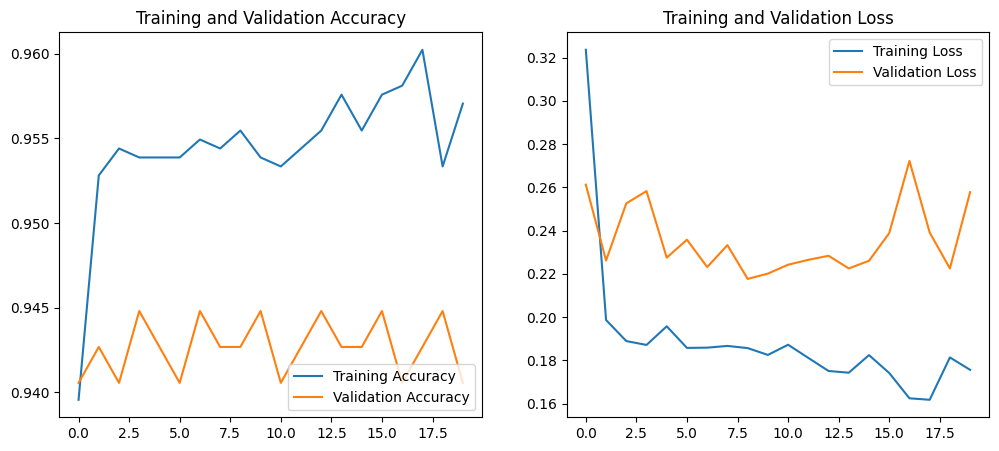

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

print(f"Final Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()